<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day4__Exercises_XP_GOLD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercise 1: Bar Graph**


Objective: Create a bar graph representing the sales data of a retail company.
Tasks:
Use a fictional dataset where the x-axis represents product categories and the y-axis represents total sales amounts.
Customize the bar graph with appropriate labels for the axes, a title, and color.
Display the graph using Matplotlib.

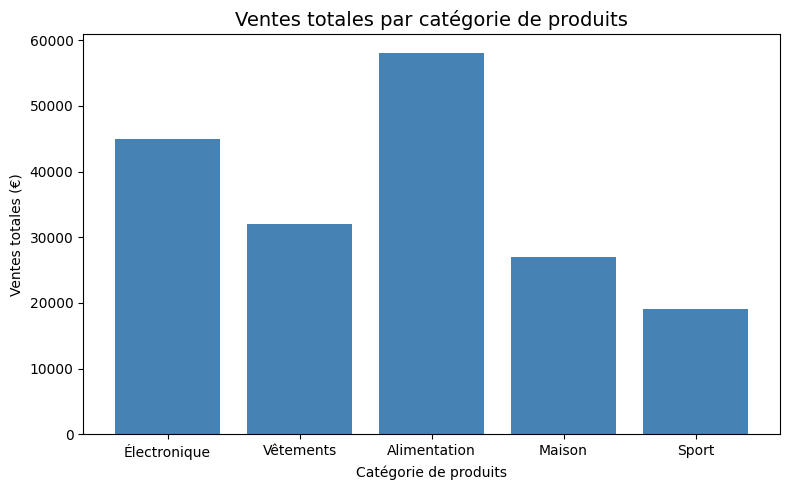

In [1]:
# ============================================================
# Exercice 1 : Bar Graph - Ventes par catégorie de produits
# ============================================================

# --- 1. Importation de la bibliothèque nécessaire ---
import matplotlib.pyplot as plt

# --- 2. Création d'un dataset fictif ---
# Axe X : catégories de produits
# Axe Y : montant total des ventes (en euros, par exemple)
categories = ["Électronique", "Vêtements", "Alimentation", "Maison", "Sport"]
sales = [45000, 32000, 58000, 27000, 19000]

# --- 3. Création du bar graph avec Matplotlib ---
plt.figure(figsize=(8, 5))

plt.bar(
    categories,
    sales,
    color="steelblue"  # couleur personnalisée des barres
)

# --- 4. Personnalisation du graphique ---
plt.title("Ventes totales par catégorie de produits", fontsize=14)
plt.xlabel("Catégorie de produits")
plt.ylabel("Ventes totales (€)")
plt.tight_layout()

# --- 5. Affichage du graphique ---
plt.show()


**Exercise 2: Hierarchical Indexing**

Objective: Filter and retrieve all days when the temperature exceeded 30°C (86°F) for cities in Canada using hierarchical indexing.
Tasks:
Create a pandas DataFrame with hierarchical indexing on ‘Country’, ‘City’, and ‘Date’.
Write Python code to filter the dataset for the specified condition.
Explain how hierarchical indexing simplifies multi-level data analysis.

In [2]:
# ============================================================
# Exercice 2 : Indexation hiérarchique - Températures par pays/ville
# ============================================================

# --- 1. Importation des bibliothèques nécessaires ---
import pandas as pd
import numpy as np

# --- 2. Création d'un dataset fictif avec données multi-niveaux ---
data = {
    "Country": ["Canada", "Canada", "Canada", "Canada",
                "USA", "USA", "USA", "USA",
                "France", "France", "France", "France"],
    "City": ["Toronto", "Toronto", "Vancouver", "Vancouver",
             "New York", "New York", "Los Angeles", "Los Angeles",
             "Paris", "Paris", "Lyon", "Lyon"],
    "Date": ["2024-07-01", "2024-07-02", "2024-07-01", "2024-07-02",
             "2024-07-01", "2024-07-02", "2024-07-01", "2024-07-02",
             "2024-07-01", "2024-07-02", "2024-07-01", "2024-07-02"],
    "Temperature": [28, 32, 22, 31, 27, 26, 34, 35, 29, 33, 30, 24]
}

df = pd.DataFrame(data)

# --- 3. Mise en place de l'indexation hiérarchique (MultiIndex) ---
# On définit Country, City et Date comme index à plusieurs niveaux.
df.set_index(["Country", "City", "Date"], inplace=True)

print("DataFrame avec indexation hiérarchique :")
print(df)

# --- 4. Filtrage : jours où la température dépasse 30°C, pour le Canada ---
# .xs() permet d'extraire une "tranche" du DataFrame correspondant
# à une valeur précise d'un niveau d'index (ici : "Canada").
canada_data = df.xs("Canada", level="Country")

# On applique ensuite un filtre booléen classique sur la colonne Temperature.
hot_days_canada = canada_data[canada_data["Temperature"] > 30]

print("\nJours où la température a dépassé 30°C au Canada :")
print(hot_days_canada)

# ============================================================
# Explication : pourquoi l'indexation hiérarchique aide ici ?
# ============================================================
# Avec un MultiIndex (Country / City / Date), on peut isoler rapidement
# un sous-ensemble de données (ex : toutes les villes d'un pays donné)
# sans avoir à écrire un filtre "df['Country'] == 'Canada'" à chaque fois.
# Cela rend le code plus lisible et plus rapide pour des analyses
# multi-niveaux (par pays, puis par ville, puis par date), surtout
# quand le dataset devient volumineux.

DataFrame avec indexation hiérarchique :
                                Temperature
Country City        Date                   
Canada  Toronto     2024-07-01           28
                    2024-07-02           32
        Vancouver   2024-07-01           22
                    2024-07-02           31
USA     New York    2024-07-01           27
                    2024-07-02           26
        Los Angeles 2024-07-01           34
                    2024-07-02           35
France  Paris       2024-07-01           29
                    2024-07-02           33
        Lyon        2024-07-01           30
                    2024-07-02           24

Jours où la température a dépassé 30°C au Canada :
                      Temperature
City      Date                   
Toronto   2024-07-02           32
Vancouver 2024-07-02           31


**Exercise 3: Advanced Filtering with Hierarchical Indices**


Objective: Filter rows in a hierarchical DataFrame based on specific criteria.
Tasks:
Use the DataFrame from Exercise 4 of the XP exercises.
Write Python code to filter and display rows where ‘Salary’ is above 50,000 within each ‘Department’.
Demonstrate how hierarchical indexing facilitates efficient filtering.

In [3]:
# ============================================================
# Exercice 3 : Filtrage avancé avec indexation hiérarchique
# ============================================================
# Objectif : filtrer les employés dont le salaire dépasse 50 000,
# en conservant la structure par département grâce au MultiIndex.

# --- 1. Importation de la bibliothèque nécessaire ---
import pandas as pd

# --- 2. Création d'un dataset fictif ---
# (À remplacer par le DataFrame réel de l'Exercice 4 des exercices XP
# si tu veux que je reprenne exactement les mêmes données.)
data = {
    "Department": ["IT", "IT", "IT", "Sales", "Sales", "Sales",
                    "HR", "HR", "Finance", "Finance"],
    "Employee": ["Alice", "Bob", "Chloe", "David", "Emma", "Farid",
                 "Grace", "Hugo", "Ines", "Jules"],
    "Salary": [55000, 48000, 62000, 51000, 47000, 53000,
               45000, 49000, 58000, 60000]
}

df = pd.DataFrame(data)

# --- 3. Mise en place de l'indexation hiérarchique ---
# On indexe le DataFrame par Department, puis par Employee.
# Cela crée une structure à deux niveaux : on peut ainsi "naviguer"
# dans les données département par département, sans recréer
# un filtre "df['Department'] == ..." chaque fois.
df.set_index(["Department", "Employee"], inplace=True)

print("DataFrame avec indexation hiérarchique (Department > Employee) :")
print(df)

# --- 4. Filtrage : salaire au-dessus de 50 000 ---
# On applique un filtre booléen classique sur la colonne Salary.
# Comme le DataFrame est indexé hiérarchiquement, le résultat
# garde automatiquement l'information du département pour chaque ligne.
high_salary = df[df["Salary"] > 50000]

print("\nEmployés avec un salaire > 50 000 (avec leur département) :")
print(high_salary)

# --- 5. Regroupement par département pour bien voir l'avantage du MultiIndex ---
# groupby(level="Department") utilise directement le niveau d'index,
# sans avoir besoin d'une colonne "Department" séparée.
print("\nNombre d'employés à salaire élevé, par département :")
print(high_salary.groupby(level="Department").size())

# ============================================================
# Explication : pourquoi l'indexation hiérarchique facilite le filtrage
# ============================================================
# 1. On évite de répéter une colonne "Department" comme simple colonne :
#    elle fait partie de la structure même du DataFrame (l'index).
# 2. Le filtrage classique (df[condition]) fonctionne normalement,
#    MAIS le résultat reste organisé par département automatiquement.
# 3. On peut ensuite regrouper ou agréger directement par niveau d'index
#    (groupby(level=...)) sans manipulation supplémentaire,
#    ce qui est très utile pour des analyses multi-niveaux
#    (ex : département > employé, ou pays > ville > date comme à l'Exercice 2).

DataFrame avec indexation hiérarchique (Department > Employee) :
                     Salary
Department Employee        
IT         Alice      55000
           Bob        48000
           Chloe      62000
Sales      David      51000
           Emma       47000
           Farid      53000
HR         Grace      45000
           Hugo       49000
Finance    Ines       58000
           Jules      60000

Employés avec un salaire > 50 000 (avec leur département) :
                     Salary
Department Employee        
IT         Alice      55000
           Chloe      62000
Sales      David      51000
           Farid      53000
Finance    Ines       58000
           Jules      60000

Nombre d'employés à salaire élevé, par département :
Department
Finance    2
IT         2
Sales      2
dtype: int64


**Exercise 4: Visualizing Movie Durations**


Objective: Create a distribution plot to visualize the durations of MCU movies.
Tasks:
Import necessary libraries (pandas, Seaborn, Matplotlib).
Load a dataset containing MCU movie information.
Use Seaborn’s distplot or histplot to visualize the distribution of movie durations.
Add a KDE overlay and customize the plot with a title.
Display the plot.


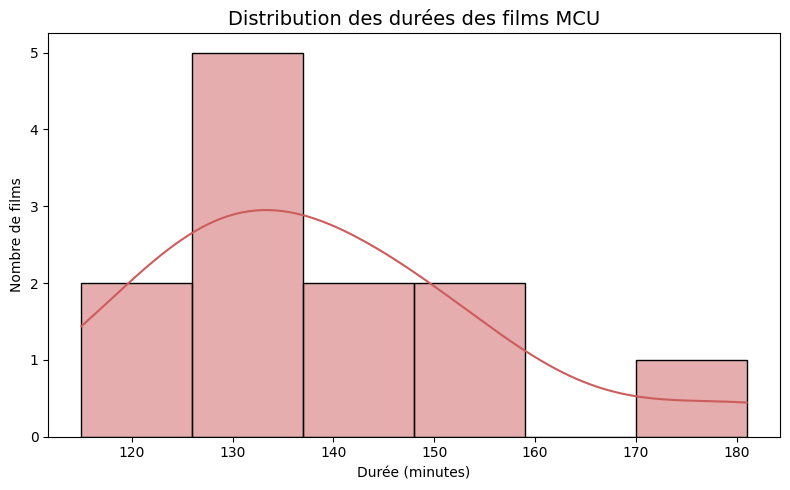

In [4]:
# ============================================================
# Exercice 4 : Visualisation des durées des films MCU
# ============================================================
# Remarque : le fichier réel des films MCU n'a pas été fourni.
# J'ai donc créé un dataset fictif (mais réaliste) avec 12 films
# pour que le code soit directement réutilisable avec ton vrai fichier.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Création du dataset fictif (à remplacer par ton vrai fichier) ---
data = {
    "title": ["Iron Man", "The Avengers", "Captain America: Civil War",
              "Black Panther", "Avengers: Endgame", "Spider-Man: Homecoming",
              "Doctor Strange", "Thor: Ragnarok", "Captain Marvel",
              "Shang-Chi", "Eternals", "Spider-Man: No Way Home"],
    "mcu_phase": [1, 1, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4],
    "duration_minutes": [126, 143, 147, 134, 181, 133, 115, 130, 123, 132, 156, 148],
    "tomato_meter": [94, 91, 91, 96, 94, 92, 89, 92, 79, 91, 47, 93],
    "audience_score": [91, 91, 89, 79, 90, 99, 86, 87, 78, 91, 78, 98],
    "production_budget": ["$140,000,000", "$220,000,000", "$250,000,000",
                           "$200,000,000", "$356,000,000", "$175,000,000",
                           "$165,000,000", "$180,000,000", "$175,000,000",
                           "$150,000,000", "$200,000,000", "$200,000,000"],
    "opening_weekend": ["$98,618,668", "$207,438,708", "$179,139,142",
                         "$202,003,951", "$357,115,007", "$117,027,503",
                         "$85,058,311", "$122,744,989", "$153,433,423",
                         "$75,388,688", "$71,297,219", "$260,138,569"],
    "domestic_box_office": ["$318,604,126", "$623,357,910", "$408,084,349",
                             "$700,059,566", "$858,373,000", "$334,201,140",
                             "$232,641,920", "$315,058,289", "$426,829,839",
                             "$224,543,292", "$164,870,234", "$814,866,759"],
    "worldwide_box_office": ["$585,366,247", "$1,518,815,515", "$1,153,304,495",
                              "$1,347,597,973", "$2,797,501,328", "$880,166,924",
                              "$677,796,076", "$854,029,191", "$1,128,274,794",
                              "$432,243,292", "$402,070,234", "$1,921,847,111"]
}
df_mcu = pd.DataFrame(data)

# --- 2. Création du graphique de distribution avec Seaborn ---
# histplot() trace un histogramme classique : il découpe les durées
# en "bins" (tranches) et compte combien de films tombent dans chaque tranche.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_mcu,
    x="duration_minutes",
    kde=True,          # ajoute une courbe lissée (Kernel Density Estimate)
                        # qui montre la tendance générale de la distribution,
                        # en complément des barres de l'histogramme
    color="indianred",
    bins=6              # nombre de tranches : à ajuster selon la taille du dataset
                        # (peu de films -> peu de bins, sinon le graphique est creux)
)

# --- 3. Personnalisation du graphique ---
plt.title("Distribution des durées des films MCU", fontsize=14)
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de films")
plt.tight_layout()

# --- 4. Affichage du graphique ---
plt.show()

# Remarque : distplot() existait dans les anciennes versions de Seaborn,
# mais il est aujourd'hui déprécié (retiré des versions récentes).
# histplot(kde=True) est l'équivalent moderne : histogramme + courbe KDE.

**Exercise 5: Box Plot of Audience and Tomato Meter Scores**


Objective: Compare the distribution of Tomato Meter scores and Audience scores using a box plot.
Tasks:
Create a new DataFrame that melts the Tomato Meter and Audience scores into a long format.
Use Seaborn’s boxplot to visualize the distributions of both scores.
Customize the plot by setting an appropriate color palette and adding a title.
Display the plot.


Aperçu du DataFrame en format long :
                        title    Score_type  Score
0                    Iron Man  tomato_meter     94
1                The Avengers  tomato_meter     91
2  Captain America: Civil War  tomato_meter     91
3               Black Panther  tomato_meter     96
4           Avengers: Endgame  tomato_meter     94


/tmp/ipykernel_3916/4030057069.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


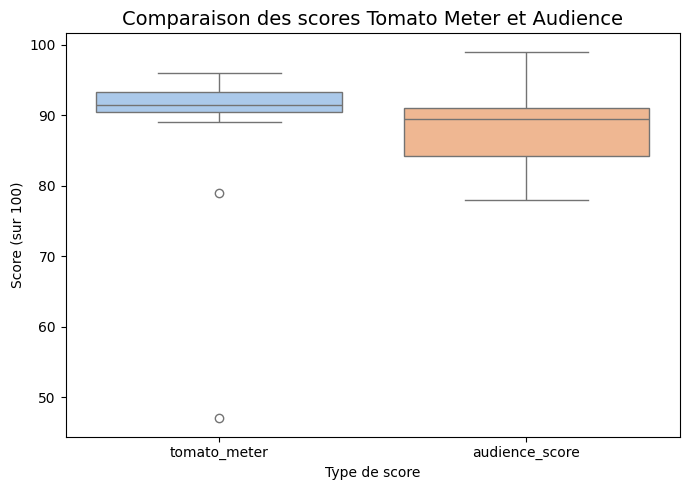

In [5]:
# ============================================================
# Exercice 5 : Box plot - Tomato Meter vs Audience Score
# ============================================================
# Utilise le même dataset fictif que l'Exercice 4 (à remplacer par
# le vrai fichier MCU une fois disponible).

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Recréation du dataset fictif ---
data = {
    "title": ["Iron Man", "The Avengers", "Captain America: Civil War",
              "Black Panther", "Avengers: Endgame", "Spider-Man: Homecoming",
              "Doctor Strange", "Thor: Ragnarok", "Captain Marvel",
              "Shang-Chi", "Eternals", "Spider-Man: No Way Home"],
    "mcu_phase": [1, 1, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4],
    "tomato_meter": [94, 91, 91, 96, 94, 92, 89, 92, 79, 91, 47, 93],
    "audience_score": [91, 91, 89, 79, 90, 99, 86, 87, 78, 91, 78, 98]
}
df_mcu = pd.DataFrame(data)

# --- 2. Transformation en format "long" avec melt() ---
# Avant : une ligne par film, avec 2 colonnes de scores (format "large").
# Après : une ligne par (film, type de score), avec une seule colonne
# "Score" -> c'est le format attendu par Seaborn pour comparer
# deux catégories sur le même axe X dans un box plot.
df_scores_long = df_mcu.melt(
    id_vars=["title"],                              # colonne(s) à garder telles quelles
    value_vars=["tomato_meter", "audience_score"],  # colonnes à "fusionner"
    var_name="Score_type",                           # nom de la nouvelle colonne (quel score ?)
    value_name="Score"                               # nom de la colonne contenant la valeur
)

print("Aperçu du DataFrame en format long :")
print(df_scores_long.head())

# --- 3. Création du box plot avec Seaborn ---
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_scores_long,
    x="Score_type",
    y="Score",
    palette="pastel"
)

# --- 4. Personnalisation du graphique ---
plt.title("Comparaison des scores Tomato Meter et Audience", fontsize=14)
plt.xlabel("Type de score")
plt.ylabel("Score (sur 100)")
plt.tight_layout()

# --- 5. Affichage du graphique ---
plt.show()

**Exercise 6: Pair Plot of Financial Data**


Objective: Use Seaborn’s pairplot to explore relationships between financial aspects of MCU movies.
Tasks:
Select relevant columns for analysis (e.g., Production Budget, Opening Weekend, Domestic Box Office, Worldwide Box Office).
Convert financial data from string to numeric if needed.
Use Seaborn’s pairplot to visualize pairwise relationships between the selected metrics.
Set hue based on the MCU phase (e.g., mcu_phase) to identify patterns related to movie phases.
Customize the plot and display it.

Aperçu après conversion en valeurs numériques :
   production_budget  opening_weekend  domestic_box_office  \
0        140000000.0       98618668.0          318604126.0   
1        220000000.0      207438708.0          623357910.0   
2        250000000.0      179139142.0          408084349.0   
3        200000000.0      202003951.0          700059566.0   
4        356000000.0      357115007.0          858373000.0   

   worldwide_box_office  
0          5.853662e+08  
1          1.518816e+09  
2          1.153304e+09  
3          1.347598e+09  
4          2.797501e+09  


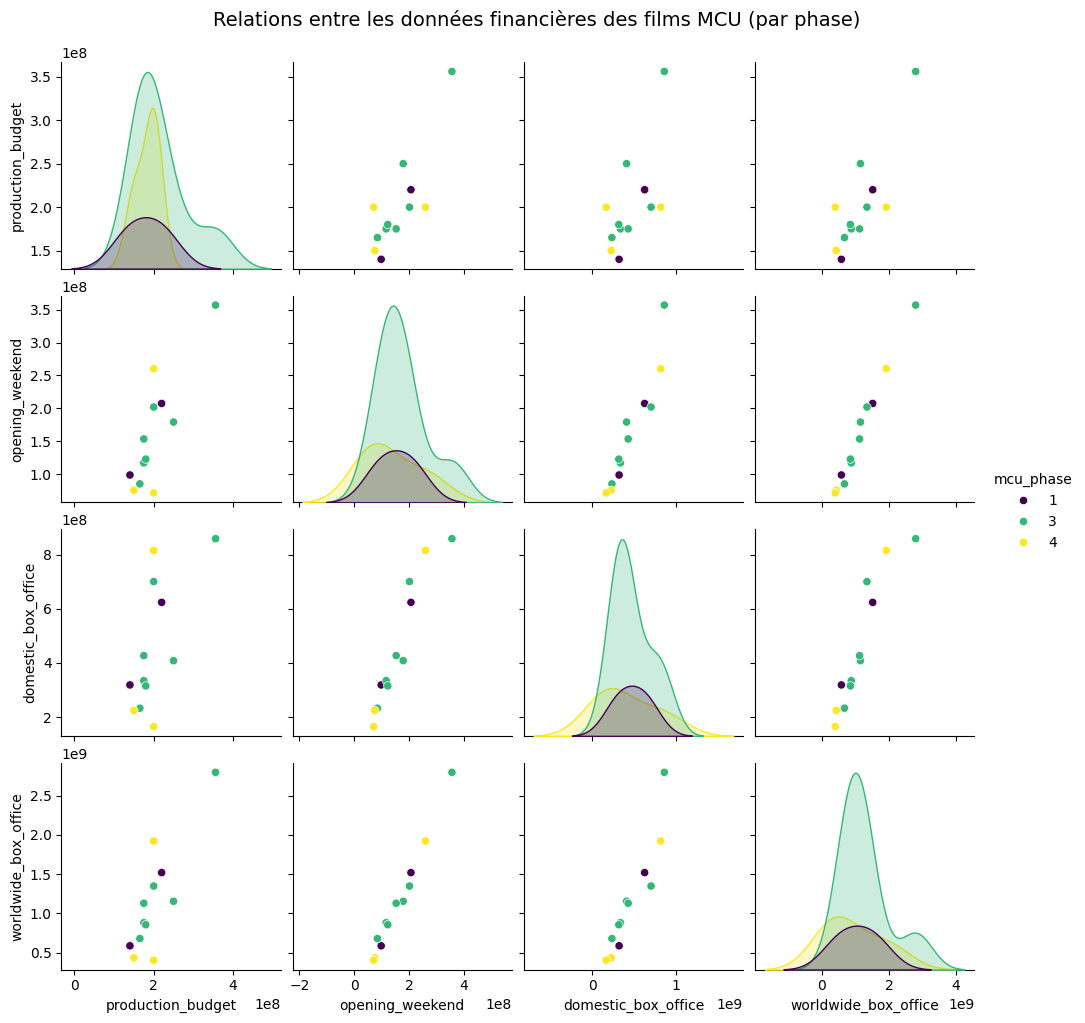

In [6]:
# ============================================================
# Exercice 6 : Pair plot - Données financières des films MCU
# ============================================================
# Utilise le même dataset fictif que les exercices 4 et 5.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Recréation du dataset fictif (valeurs financières en texte) ---
data = {
    "title": ["Iron Man", "The Avengers", "Captain America: Civil War",
              "Black Panther", "Avengers: Endgame", "Spider-Man: Homecoming",
              "Doctor Strange", "Thor: Ragnarok", "Captain Marvel",
              "Shang-Chi", "Eternals", "Spider-Man: No Way Home"],
    "mcu_phase": [1, 1, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4],
    "production_budget": ["$140,000,000", "$220,000,000", "$250,000,000",
                           "$200,000,000", "$356,000,000", "$175,000,000",
                           "$165,000,000", "$180,000,000", "$175,000,000",
                           "$150,000,000", "$200,000,000", "$200,000,000"],
    "opening_weekend": ["$98,618,668", "$207,438,708", "$179,139,142",
                         "$202,003,951", "$357,115,007", "$117,027,503",
                         "$85,058,311", "$122,744,989", "$153,433,423",
                         "$75,388,688", "$71,297,219", "$260,138,569"],
    "domestic_box_office": ["$318,604,126", "$623,357,910", "$408,084,349",
                             "$700,059,566", "$858,373,000", "$334,201,140",
                             "$232,641,920", "$315,058,289", "$426,829,839",
                             "$224,543,292", "$164,870,234", "$814,866,759"],
    "worldwide_box_office": ["$585,366,247", "$1,518,815,515", "$1,153,304,495",
                              "$1,347,597,973", "$2,797,501,328", "$880,166,924",
                              "$677,796,076", "$854,029,191", "$1,128,274,794",
                              "$432,243,292", "$402,070,234", "$1,921,847,111"]
}
df_mcu = pd.DataFrame(data)

# --- 2. Conversion des colonnes financières de texte vers numérique ---
# On retire le symbole "$" et les virgules, puis on convertit en float
financial_columns = ["production_budget", "opening_weekend",
                      "domestic_box_office", "worldwide_box_office"]

for col in financial_columns:
    df_mcu[col] = (
        df_mcu[col]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

print("Aperçu après conversion en valeurs numériques :")
print(df_mcu[financial_columns].head())

# --- 3. Sélection des colonnes pertinentes pour le pair plot ---
columns_to_plot = financial_columns + ["mcu_phase"]
df_pairplot = df_mcu[columns_to_plot]

# --- 4. Création du pair plot avec Seaborn ---
# hue="mcu_phase" permet de colorer les points selon la phase du MCU,
# pour repérer d'éventuels patterns liés aux différentes phases
pairplot_fig = sns.pairplot(
    df_pairplot,
    hue="mcu_phase",
    palette="viridis",
    diag_kind="kde"
)

# --- 5. Personnalisation et affichage ---
pairplot_fig.fig.suptitle(
    "Relations entre les données financières des films MCU (par phase)",
    y=1.02,
    fontsize=14
)

plt.show()